In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\SAKTHI\Desktop\myproject\PatrolIQ\processing_data\chicago_crime_stratified_months.csv")

1. Understanding dataset

In [2]:

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50) 

In [3]:
pd.DataFrame(
    {
        "column":df.columns,
        "Data_types":[df[col].dtype for col in df.columns],
        "No_Uniques_value/total value":[df[col].nunique() for col in df.columns],
        "Uniques_values":[df[col].unique()[:5] for col in df.columns],
        "missing_value":[df[col].isnull().sum() for col in df.columns],
        "total_value":[df[col].notnull().sum() for col in df.columns]
    }
)

,column,Data_types,No_Uniques_value/total value,Uniques_values,missing_value,total_value
0,id,int64,510000,"[6109293, 7734880, 5831877, 9593289, 1359660]",0,510000
1,case_number,object,509954,"[HP204796, HS542237, HN562420, HX243562, G064330]",0,510000
2,date,object,220233,"[2008-02-28T08:00:00.000, 2010-09-30T18:45:00....",0,510000
3,block,object,40164,"[016XX W BEACH AVE, 041XX W 21ST ST, 062XX S S...",0,510000
4,iucr,object,374,"[0810, 2024, 2027, 1320, 0820]",0,510000
5,primary_type,object,33,"[THEFT, NARCOTICS, CRIMINAL DAMAGE, BATTERY, O...",0,510000
6,description,object,489,"[OVER $500, POSS: HEROIN(WHITE), POSS: CRACK, ...",0,510000
7,location_description,object,173,"[STREET, ALLEY, SIDEWALK, SMALL RETAIL STORE, ...",1071,508929
8,arrest,bool,2,"[False, True]",0,510000
9,domestic,bool,2,"[False, True]",0,510000


In [4]:
df.describe()

,id,beat,district,ward,community_area,x_coordinate,y_coordinate,year,latitude,longitude
count,5.100000e+05,510000.000000,509999.000000,484827.000000,484848.000000,5.050640e+05,5.050640e+05,510000.00000,505064.000000,505064.000000
mean,8.571524e+06,1174.789092,11.284297,22.880017,37.235649,1.164759e+06,1.885936e+06,2013.00000,41.842602,-87.670912
std,3.749383e+06,703.301442,6.971017,13.875492,21.521578,1.679214e+04,3.226233e+04,7.21111,0.088755,0.060909
min,6.750000e+02,111.000000,1.000000,1.000000,0.000000,0.000000e+00,0.000000e+00,2001.00000,36.619446,-91.686566
25%,5.436289e+06,614.000000,6.000000,10.000000,23.000000,1.153150e+06,1.858987e+06,2007.00000,41.768460,-87.712994
50%,9.198246e+06,1033.000000,10.000000,23.000000,32.000000,1.166368e+06,1.891406e+06,2013.00000,41.857596,-87.664977
75%,1.187583e+07,1724.000000,17.000000,34.000000,56.000000,1.176442e+06,1.909355e+06,2019.00000,41.906939,-87.627910
max,1.413830e+07,2535.000000,31.000000,50.000000,77.000000,1.205119e+06,1.951532e+06,2025.00000,42.022654,-87.524529


In [5]:
numerical = df.select_dtypes(include=["int64", "float64"]).columns
categorical = df.select_dtypes(include=["object"]).columns
boolean = df.select_dtypes(include="bool").columns

pd.DataFrame({
    "Numerical": pd.Series(numerical),
    "Categorical": pd.Series(categorical),
    "Boolean": pd.Series(boolean)
})

,Numerical,Categorical,Boolean
0,id,case_number,arrest
1,beat,date,domestic
2,district,block,NaN
3,ward,iucr,NaN
4,community_area,primary_type,NaN
5,x_coordinate,description,NaN
6,y_coordinate,location_description,NaN
7,year,fbi_code,NaN
8,latitude,updated_on,NaN
9,longitude,location,NaN


2. HANDLE MISSING VALUE

In [6]:
df.isnull().sum().sort_values(ascending=False)


ward                    25173
community_area          25152
location                 4936
y_coordinate             4936
longitude                4936
latitude                 4936
x_coordinate             4936
location_description     1071
district                    1
iucr                        0
case_number                 0
id                          0
block                       0
date                        0
primary_type                0
description                 0
arrest                      0
domestic                    0
beat                        0
fbi_code                    0
year                        0
updated_on                  0
dtype: int64

In [10]:
for col in df.columns:
    per_null = (df[col].isnull().sum()/len(df))*100
    data_type = df[col].dtypes
    print("|",col,"|",per_null,"|",data_type,"|")

| id | 0.0 | int64 |
| case_number | 0.0 | object |
| date | 0.0 | object |
| block | 0.0 | object |
| iucr | 0.0 | object |
| primary_type | 0.0 | object |
| description | 0.0 | object |
| location_description | 0.21 | object |
| arrest | 0.0 | bool |
| domestic | 0.0 | bool |
| beat | 0.0 | int64 |
| district | 0.000196078431372549 | float64 |
| ward | 4.935882352941177 | float64 |
| community_area | 4.931764705882353 | float64 |
| fbi_code | 0.0 | object |
| x_coordinate | 0.9678431372549019 | float64 |
| y_coordinate | 0.9678431372549019 | float64 |
| year | 0.0 | int64 |
| updated_on | 0.0 | object |
| latitude | 0.9678431372549019 | float64 |
| longitude | 0.9678431372549019 | float64 |
| location | 0.9678431372549019 | object |


In [27]:
# .loc[rows, columns]
df.loc[df['district'].isnull(), 'district']

91419   NaN
Name: district, dtype: float64

In [28]:
df_cols = [
    "community_area", "ward", "location", "y_coordinate", 
    "longitude", "latitude", "x_coordinate", "location_description", "district"
]
for col in df_cols:
    print(f"--- Missing values in: {col} ---")
    print(df[col][df[col].isnull()])
    print("\n")

--- Missing values in: community_area ---
4        NaN
96       NaN
100      NaN
139      NaN
168      NaN
          ..
509924   NaN
509935   NaN
509947   NaN
509961   NaN
509997   NaN
Name: community_area, Length: 25152, dtype: float64


--- Missing values in: ward ---
4        NaN
96       NaN
100      NaN
139      NaN
168      NaN
          ..
509924   NaN
509935   NaN
509947   NaN
509961   NaN
509997   NaN
Name: ward, Length: 25173, dtype: float64


--- Missing values in: location ---
198       NaN
449       NaN
478       NaN
555       NaN
586       NaN
         ... 
509662    NaN
509687    NaN
509743    NaN
509951    NaN
509989    NaN
Name: location, Length: 4936, dtype: object


--- Missing values in: y_coordinate ---
198      NaN
449      NaN
478      NaN
555      NaN
586      NaN
          ..
509662   NaN
509687   NaN
509743   NaN
509951   NaN
509989   NaN
Name: y_coordinate, Length: 4936, dtype: float64


--- Missing values in: longitude ---
198      NaN
449      NaN
478      

In [29]:
# Drop rows due to Less than 5% 
drop_row = [
    "community_area", "ward", "location", "y_coordinate", 
    "longitude", "latitude", "x_coordinate", "location_description", "district"
]

print("Before dropping rows:")
print(df[drop_row].isnull().sum())

df.dropna(subset=drop_row, inplace=True)

print("\nAfter dropping rows:")
print(df[drop_row].isnull().sum())


Before dropping rows:
community_area          25152
ward                    25173
location                 4936
y_coordinate             4936
longitude                4936
latitude                 4936
x_coordinate             4936
location_description     1071
district                    1
dtype: int64

After dropping rows:
community_area          0
ward                    0
location                0
y_coordinate            0
longitude               0
latitude                0
x_coordinate            0
location_description    0
district                0
dtype: int64


In [30]:
pd.DataFrame(
    {
        "column":df.columns,
        "Data_types":[df[col].dtype for col in df.columns],
        "No_Uniques_value/total value":[df[col].nunique() for col in df.columns],
        "Uniques_values":[df[col].unique()[:5] for col in df.columns],
        "missing_value":[df[col].isnull().sum() for col in df.columns],
        "total_value":[df[col].notnull().sum() for col in df.columns]
    }
)

,column,Data_types,No_Uniques_value/total value,Uniques_values,missing_value,total_value
0,id,int64,479440,"[6109293, 7734880, 5831877, 9593289, 3630013]",0,479440
1,case_number,object,479394,"[HP204796, HS542237, HN562420, HX243562, HK722...",0,479440
2,date,object,208454,"[2008-02-28T08:00:00.000, 2010-09-30T18:45:00....",0,479440
3,block,object,30620,"[016XX W BEACH AVE, 041XX W 21ST ST, 062XX S S...",0,479440
4,iucr,object,370,"[0810, 2024, 2027, 1320, 0486]",0,479440
5,primary_type,object,33,"[THEFT, NARCOTICS, CRIMINAL DAMAGE, BATTERY, O...",0,479440
6,description,object,485,"[OVER $500, POSS: HEROIN(WHITE), POSS: CRACK, ...",0,479440
7,location_description,object,172,"[STREET, ALLEY, SIDEWALK, RESIDENCE, APARTMENT]",0,479440
8,arrest,bool,2,"[False, True]",0,479440
9,domestic,bool,2,"[False, True]",0,479440


In [31]:
df['primary_type'].unique()

array(['THEFT', 'NARCOTICS', 'CRIMINAL DAMAGE', 'BATTERY',
       'OTHER OFFENSE', 'PROSTITUTION', 'ASSAULT', 'ROBBERY',
       'CRIMINAL TRESPASS', 'WEAPONS VIOLATION', 'BURGLARY',
       'MOTOR VEHICLE THEFT', 'CONCEALED CARRY LICENSE VIOLATION',
       'SEX OFFENSE', 'DECEPTIVE PRACTICE', 'OFFENSE INVOLVING CHILDREN',
       'HOMICIDE', 'OBSCENITY', 'CRIM SEXUAL ASSAULT',
       'PUBLIC PEACE VIOLATION', 'GAMBLING', 'KIDNAPPING',
       'INTERFERENCE WITH PUBLIC OFFICER', 'INTIMIDATION', 'ARSON',
       'STALKING', 'CRIMINAL SEXUAL ASSAULT', 'LIQUOR LAW VIOLATION',
       'NON-CRIMINAL', 'OTHER NARCOTIC VIOLATION', 'HUMAN TRAFFICKING',
       'PUBLIC INDECENCY', 'RITUALISM'], dtype=object)

In [32]:
numerical = df.select_dtypes(include=["int64", "float64"]).columns
numerical

Index(['id', 'beat', 'district', 'ward', 'community_area', 'x_coordinate',
       'y_coordinate', 'year', 'latitude', 'longitude'],
      dtype='object')

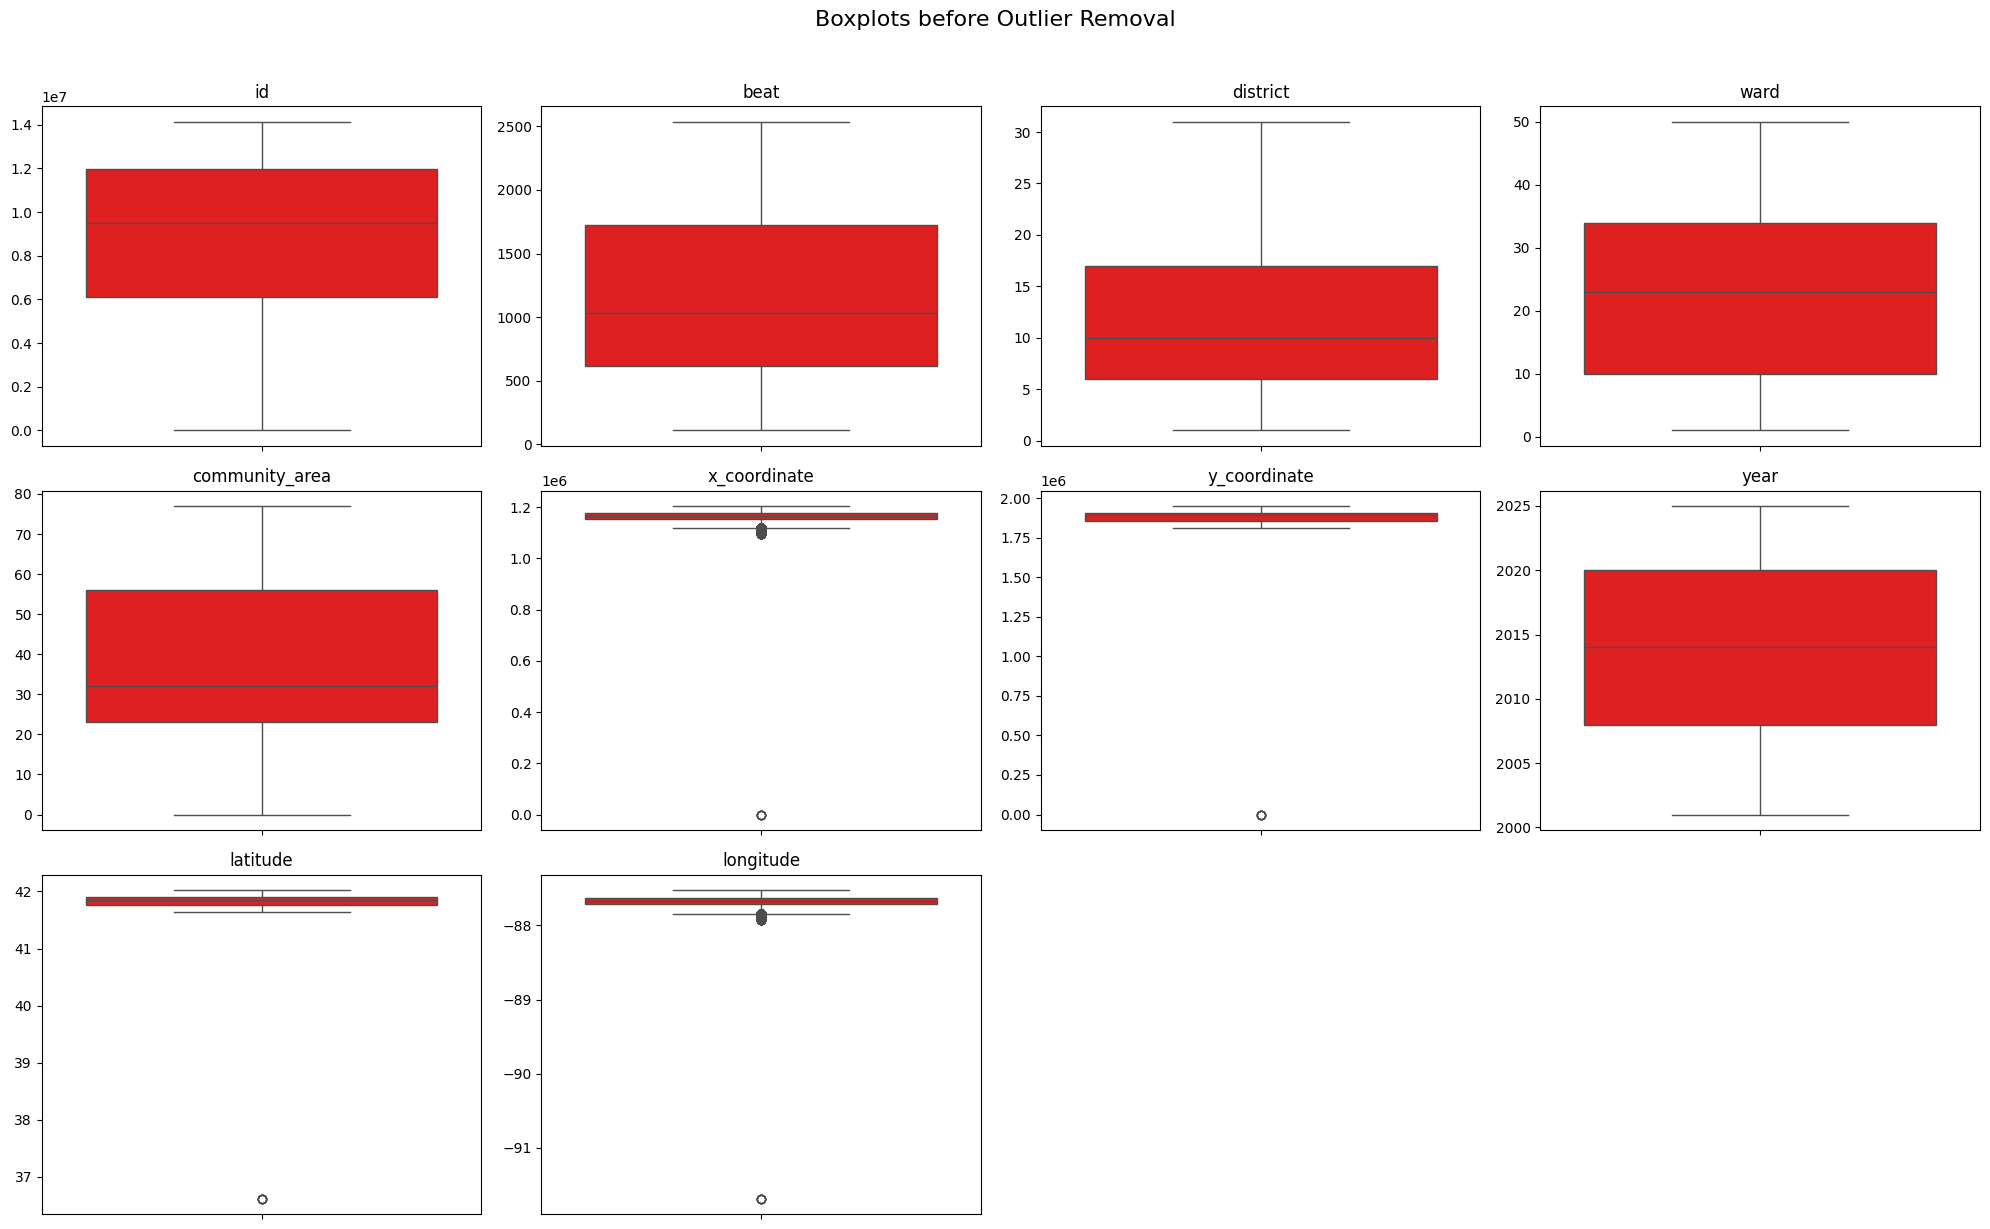

In [33]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

cols = 4
rows = math.ceil(len(numerical) / cols)

plt.figure(figsize=(20, rows * 4))
plt.suptitle("Boxplots before Outlier Removal", fontsize=16, y=1.02)

for i, col in enumerate(numerical):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[col], color='red')
    plt.title(col)
    plt.ylabel("")

plt.tight_layout()
plt.show()

id: 0 outliers (0.00%)
beat: 0 outliers (0.00%)
district: 0 outliers (0.00%)
ward: 0 outliers (0.00%)
community_area: 0 outliers (0.00%)
x_coordinate: 2164 outliers (0.45%)
y_coordinate: 5 outliers (0.00%)
year: 0 outliers (0.00%)
latitude: 5 outliers (0.00%)
longitude: 2164 outliers (0.45%)


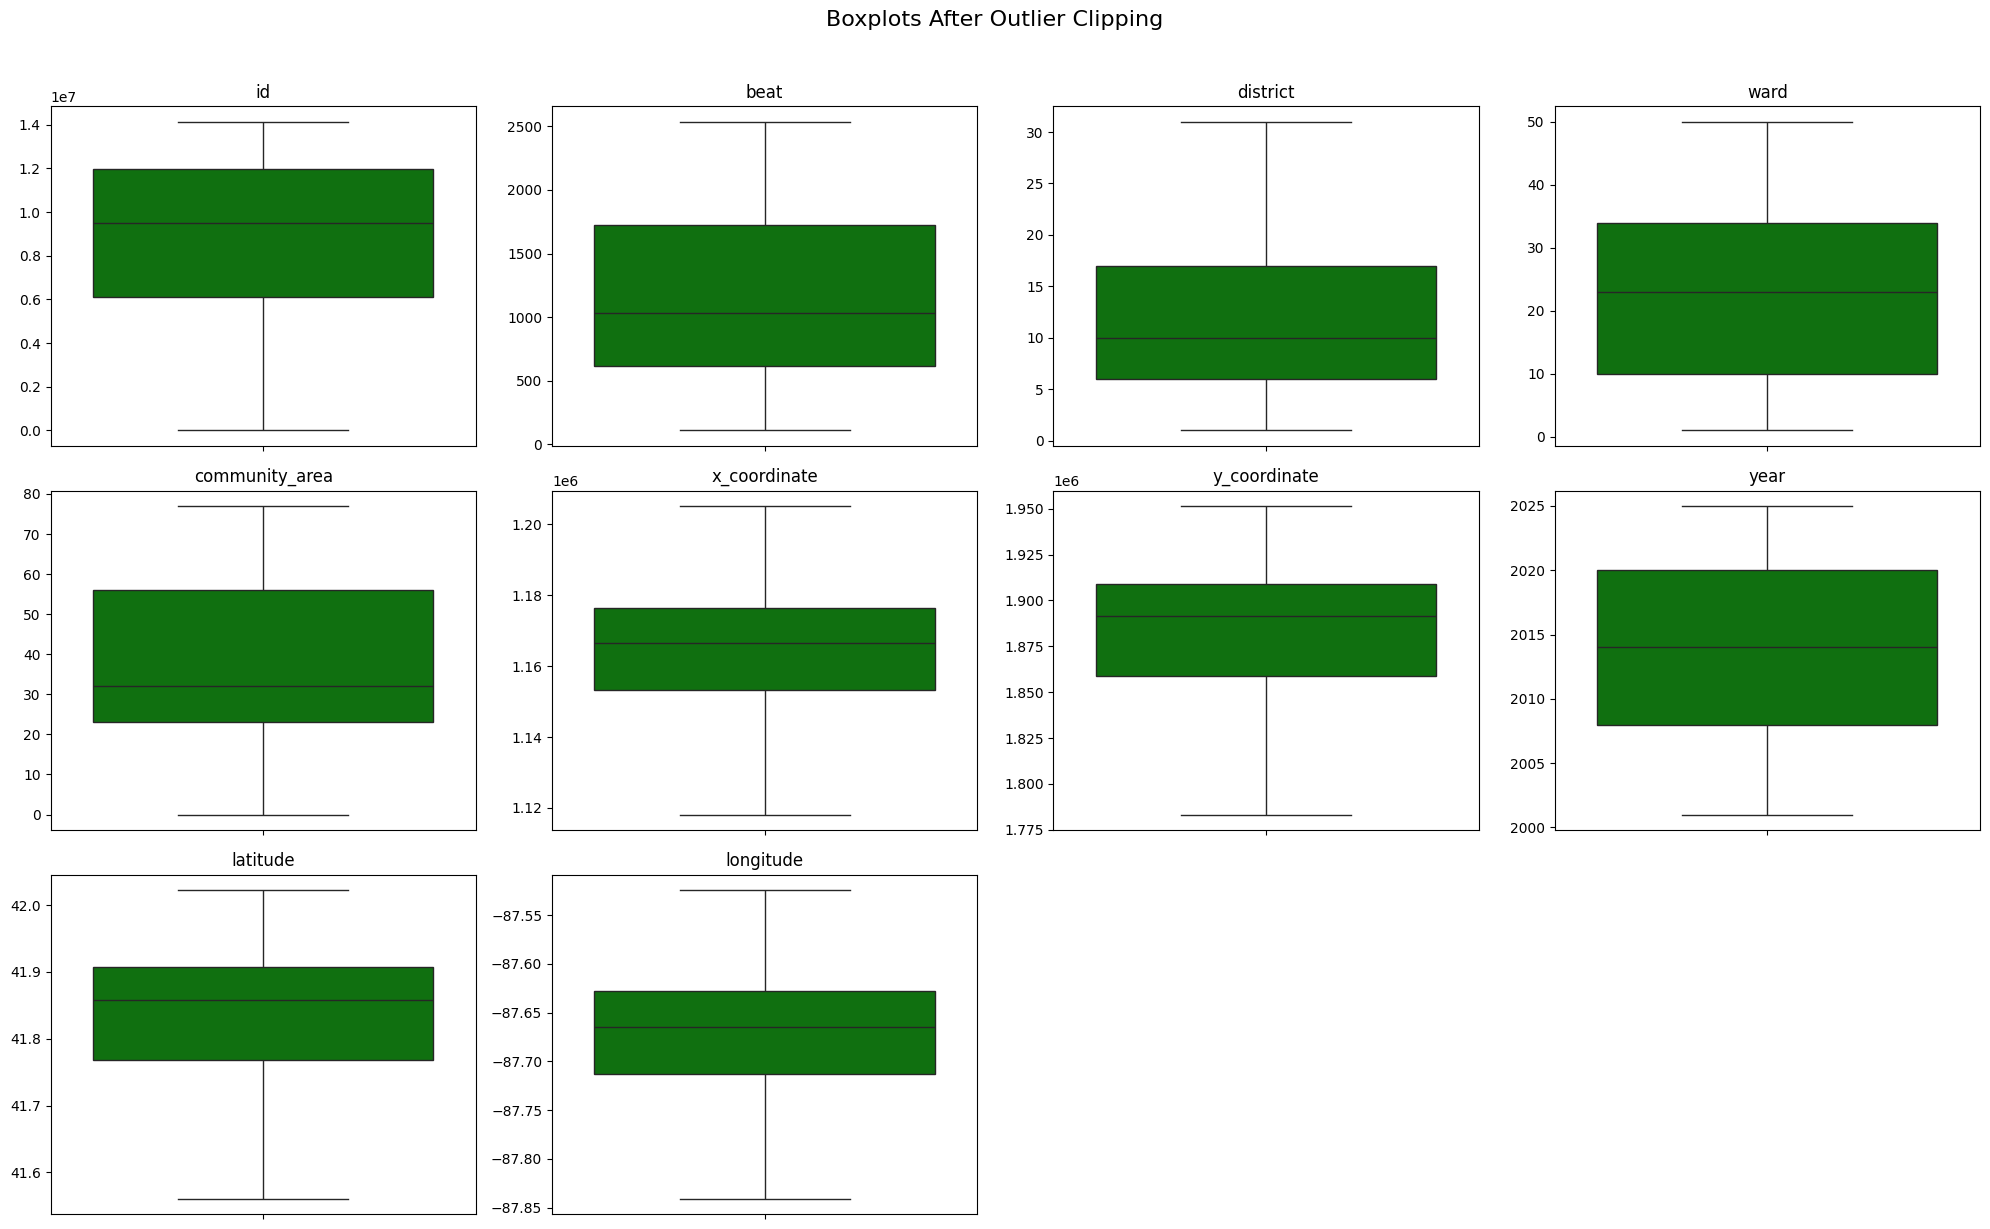

In [34]:
import numpy as np

def clip_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Count outliers
    outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    percent_outliers = (outliers_count / len(df)) * 100
    print(f"{col}: {outliers_count} outliers ({percent_outliers:.2f}%)")
    # Clip
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    return df

# Apply to df (make a copy to preserve original)
for col in numerical:
    df = clip_outliers(df, col)

# Plot AFTER boxplots
cols = 4
rows = math.ceil(len(numerical) / cols)

plt.figure(figsize=(20, rows * 4))
plt.suptitle("Boxplots After Outlier Clipping", fontsize=16, y=1.02)

for i, col in enumerate(numerical):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[col], color='green')
    plt.title(col)
    plt.ylabel("")

plt.tight_layout()
plt.show()

In [35]:
df.to_csv(r"C:\Users\SAKTHI\Desktop\myproject\PatrolIQ\data\Cleaned_chiago_data.csv",index=False)